In [1]:
library("ggplot2")
library("readxl")
library("reshape2")
library("ggsignif")

STATE_COLOURS <- c(AM = "#E7BC0C", EcM = "#23B9AF", ErM = "#6B6CF2", NM = "#11E823", NMAM = "#2D2E30", EcMAM = "#E71A23")
TRAIT_NAMES <- c(F00679 = "RD", F00727 = "SRL", F00709 = "RTD")

In [2]:
# show the variations in RD, SRL and RTD - grouped by mycorrhizal states

states <- readxl::read_xlsx("../../data/chapter2/FRED/subsets/final.xlsx", sheet = "final")[, c("binominal", "state")]
states$binominal <- gsub(states$binominal, pattern = ' ', replacement = '_')

traits <- read.csv("../../data/chapter2/FRED/subsets/continuous_raw.csv")[, c("binominal", "F00679", "F00727", "F00709")]

data <- merge(x = traits, by.x = "binominal", y = states, by.y = "binominal", all.x = TRUE)
data$cols <- unname(STATE_COLOURS[data$state]) # marker colours
head(data)

,binominal,F00679,F00727,F00709,state,cols
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,Abies_alba,0.4960000,22.12000,0.2400000,EcM,#23B9AF
2,Abies_alba,0.5430000,12.86000,0.3400000,EcM,#23B9AF
3,Abies_alba,0.6200000,61.10000,0.1530000,EcM,#23B9AF
4,Abies_nephrolepis,0.4152333,27.04586,0.2797059,EcM,#23B9AF
5,Acacia_auriculiformis,0.3831300,93.62000,0.2500000,EcMAM,#E71A23
6,Acacia_auriculiformis,0.5098500,21.93000,0.3400000,EcMAM,#E71A23


In [3]:
df <- reshape2:::melt.data.frame(data, variable.name = "trait", value.name = "value", measure.vars = c("F00679", "F00709", "F00727"))[, -1] # we don't need the species names after merging
df$value <- log(df$value) # log transform before plotting
df$trait <- unname(TRAIT_NAMES[df$trait])
head(df)

,state,cols,trait,value
,<chr>,<chr>,<chr>,<dbl>
1,EcM,#23B9AF,RD,-0.7011794
2,EcM,#23B9AF,RD,-0.6106460
3,EcM,#23B9AF,RD,-0.4780358
4,EcM,#23B9AF,RD,-0.8789147
5,EcMAM,#E71A23,RD,-0.9593809
6,EcMAM,#E71A23,RD,-0.6736387


In [20]:
comps <- combn(names(STATE_COLOURS), m = 2, simplify = FALSE)#[[1]][1]
comps

[[1]]
[1] "AM"  "EcM"

[[2]]
[1] "AM"  "ErM"

[[3]]
[1] "AM" "NM"

[[4]]
[1] "AM"   "NMAM"

[[5]]
[1] "AM"    "EcMAM"

[[6]]
[1] "EcM" "ErM"

[[7]]
[1] "EcM" "NM" 

[[8]]
[1] "EcM"  "NMAM"

[[9]]
[1] "EcM"   "EcMAM"

[[10]]
[1] "ErM" "NM" 

[[11]]
[1] "ErM"  "NMAM"

[[12]]
[1] "ErM"   "EcMAM"

[[13]]
[1] "NM"   "NMAM"

[[14]]
[1] "NM"    "EcMAM"

[[15]]
[1] "NMAM"  "EcMAM"

In [37]:
data.frame(row.names = comps)#[, names(STATE_COLOURS)]

"c(""AM"", ""EcM"")"
"c(""AM"", ""ErM"")"
"c(""AM"", ""NM"")"
"c(""AM"", ""NMAM"")"
"c(""AM"", ""EcMAM"")"
"c(""EcM"", ""ErM"")"
"c(""EcM"", ""NM"")"
"c(""EcM"", ""NMAM"")"
"c(""EcM"", ""EcMAM"")"
"c(""ErM"", ""NM"")"
"c(""ErM"", ""NMAM"")"


In [43]:

ttest$p.value

[1] 8.294029e-05

In [47]:
# figure out for each trait which state pairs show significantly difference means



for (pair in comps){
    #
    ttest <- t.test(x = subset(data, state == pair[1])[, "F00679"], y = subset(data, state == pair[2])[, "F00679"])
    if(ttest$p.value < 0.05) print(pair)#, " ", ttest$p.value))
}


[1] "AM"  "EcM"
[1] "AM"  "ErM"
[1] "AM" "NM"
[1] "AM"    "EcMAM"
[1] "EcM" "ErM"
[1] "EcM" "NM" 
[1] "EcM"  "NMAM"
[1] "EcM"   "EcMAM"
[1] "ErM" "NM" 
[1] "ErM"  "NMAM"
[1] "ErM"   "EcMAM"
[1] "NM"   "NMAM"
[1] "NMAM"  "EcMAM"


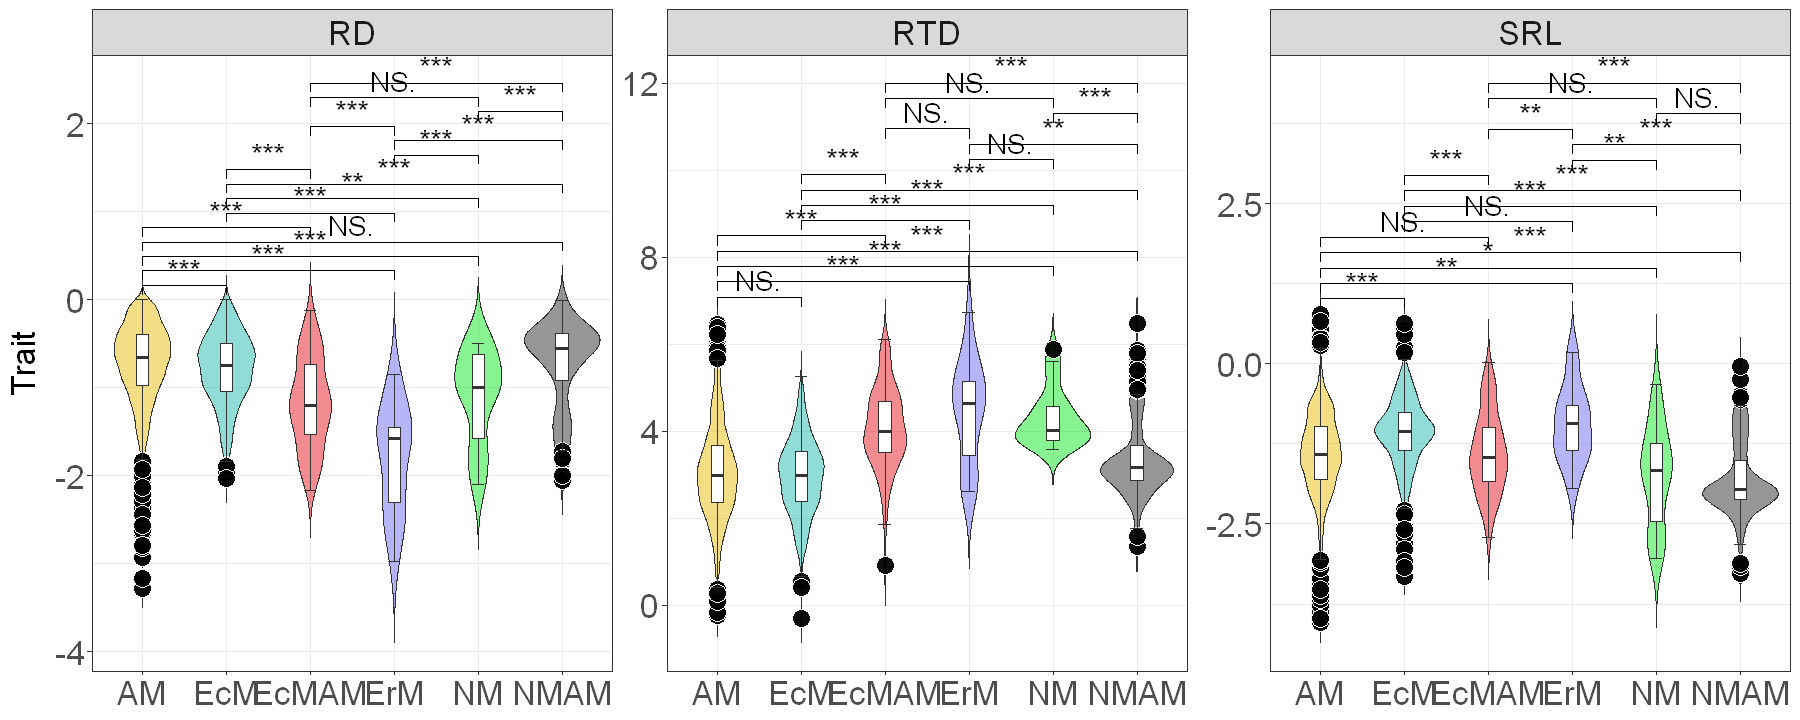

In [28]:
options(repr.plot.width = 15, repr.plot.height = 6)

p <- ggplot(aes(x = state, y = value, group = state, bg = I(cols)), data = df) +
        geom_violin(alpha = 0.5, trim = FALSE) +
        geom_boxplot(fill = "white", width = 0.15, outlier.shape = 21, outlier.fill = "black", outlier.colour = "white", outlier.alpha = 0.95, outlier.size = 5, staplewidth = 1) +
        # https://const-ae.github.io/ggsignif/
        # to avoid overlap - https://stackoverflow.com/questions/72820769/adding-significance-brackets-to-ggplot-geom-bar-object-in-r
        # y_position = seq(from = 1, to = 2, length.out = length(comps))
        geom_signif(comparisons = comps, map_signif_level = TRUE, textsize = 6, step_increase = 0.05) + 
        facet_wrap(~trait, scales = "free") +
        ylab("Trait") +
        theme_bw() +
        theme(axis.title.x = element_blank(), axis.title.y = element_text(size=20), axis.text = element_text(size = 20), strip.text = element_text(size=20))

plot(p)
# ggsave(plot = p, filename = "../../plots/FRED4-traits-all-records.png", device = "png", height = 10, width = 32, dpi = 800)

In [86]:
avgs <- aggregate.data.frame(data, cbind(F00679, F00727, F00709)~binominal, FUN = mean)
avgs <- merge(x = avgs, by.x = "binominal", y = states, by.y = "binominal", all.x = TRUE)
head(avgs)

,binominal,F00679,F00727,F00709,state
,<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,Abies_alba,0.5530000,32.02667,0.2443333,EcM
2,Abies_nephrolepis,0.4152333,27.04586,0.2797059,EcM
3,Acacia_auriculiformis,0.4911167,37.35333,0.2933333,EcMAM
4,Acacia_crassicarpa,0.2259300,108.28000,0.3600000,EcMAM
5,Acacia_mangium,0.2525500,99.19000,0.2900000,EcMAM
6,Acer_barbinerve,0.2523000,143.67897,0.1528288,AM


In [90]:
df_avgs <- reshape2:::melt.data.frame(avgs, variable.name = "trait", value.name = "value", measure.vars = c("F00679", "F00709", "F00727"))[, -1]
df_avgs$value <- log(df_avgs$value)
df_avgs$trait <- unname(TRAIT_NAMES[df_avgs$trait])
df_avgs$cols <- STATE_COLOURS[df_avgs$state]

head(df_avgs)

,state,trait,value,cols
,<chr>,<chr>,<dbl>,<chr>
1,EcM,RD,-0.5923973,#23B9AF
2,EcM,RD,-0.8789147,#23B9AF
3,EcMAM,RD,-0.7110736,#E71A23
4,EcMAM,RD,-1.4875301,#E71A23
5,EcMAM,RD,-1.3761460,#E71A23
6,AM,RD,-1.3771364,#E7BC0C


In [92]:
options(repr.plot.width = 15, repr.plot.height = 6)

p <- ggplot(aes(x = state, y = value, group = state, bg = I(cols)), data = df_avgs) +
        geom_violin(alpha = 0.5, trim = FALSE) +
        geom_boxplot(fill = "white", width = 0.15, outlier.shape = 21, outlier.fill = "black", outlier.colour = "white", outlier.alpha = 0.95, outlier.size = 5) +
        facet_wrap(~trait, scales = "free") +
        theme_bw() +
        ylab("Trait") +
        theme(axis.title.x = element_blank(), axis.title.y = element_text(size=20), axis.text = element_text(size = 20), strip.text = element_text(size=20))

ggsave(plot = p, filename = "../../plots/FRED4-traits-averages.png", device = "png", height = 10, width = 32, dpi = 800)